In [24]:
import numpy as np
import keras
import datetime
import os
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from keras.datasets import imdb
from time import time
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from tmu.models.autoencoder.autoencoder import TMAutoEncoder
from contextlib import redirect_stdout
from tqdm import tqdm

target_words = ['london', 'terrible', 'lousy', 'abysmal', 'crap', 'city', 'brilliant', 'excellent', 'superb', 'magnificent', 'marvellous', 'truck', 'plane', 'car', 'cars', 'motorcycle',  'scary', 'frightening', 'terrifying', 'horrifying', 'funny', 'comic', 'hilarious', 'witty']

home_dir = os.path.expanduser("~")
root_folder = os.path.join(home_dir, "tmu_results")
if not os.path.exists(root_folder):
    os.makedirs(root_folder)

In [25]:
NUM_WORDS=10000
INDEX_FROM=2
train,test = keras.datasets.imdb.load_data(num_words=NUM_WORDS, index_from=INDEX_FROM)
train_x,train_y = train
test_x,test_y = test
print("the number of reviews in train set =",train_x.size)
word_to_id = keras.datasets.imdb.get_word_index()
word_to_id = {k:(v+INDEX_FROM) for k,v in word_to_id.items()}

word_to_id["<PAD>"] = 0
word_to_id["<START>"] = 1
word_to_id["<UNK>"] = 2

id_to_word = {value:key for key,value in word_to_id.items()}
training_documents = []
for i in range(train_y.shape[0]):
    terms = []
    for word_id in train_x[i]:
        terms.append(id_to_word[word_id].lower())
              
    training_documents.append(terms)

testing_documents = []
for i in range(test_y.shape[0]):
    terms = []
    for word_id in test_x[i]:
        terms.append(id_to_word[word_id].lower())

    testing_documents.append(terms)
def tokenizer(s):
    return s

vectorizer_X = CountVectorizer(tokenizer=tokenizer, lowercase=False, binary = False)
X_train = vectorizer_X.fit_transform(training_documents)
feature_names = vectorizer_X.get_feature_names_out()
number_of_features = vectorizer_X.get_feature_names_out().shape[0]
X_test = vectorizer_X.transform(testing_documents)
output_active = np.empty(len(target_words), dtype=np.uint32)
for i in range(len(target_words)):
    target_word = target_words[i]
    target_id = vectorizer_X.vocabulary_[target_word]
    output_active[i] = target_id

the number of reviews in train set = 25000


/opt/conda/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [26]:
num_segments = len(target_words)
step_size = int(360 / num_segments)
color_dict = {}
hue = 0
for word in target_words:
    color = plt.get_cmap('hsv')(hue / 360.0)
    color = mcolors.to_rgb(color)
    hex_color = mcolors.rgb2hex(color)
    color_dict[word] = hex_color
    hue += step_size

In [32]:
current_time = datetime.datetime.now()
test_id = current_time.strftime("%Y%m%d%H%M%S")
result_filename = f"result_{test_id}.txt"
while os.path.exists(os.path.join(root_folder, test_id)):
        test_id = str(uuid.uuid4())
test_dir = os.path.join(root_folder, test_id)
os.makedirs(test_dir)

result_filepath = os.path.join(test_dir, result_filename)
with open(result_filepath, 'w') as file, redirect_stdout(file):
    
    clause_weight_threshold = 0
    number_of_examples = 4000
    factor = 4
    T = factor*40
    s = 5.0
    clauses = factor*10
    
    categories = 4
    accumulation = 24
    
    if categories > 0:
        tm = TMAutoEncoder(clauses, T, s, output_active, max_included_literals=3, accumulation=accumulation, feature_negation=False, platform='CPU', output_balancing=True, categories=categories)
    else:
        tm = TMAutoEncoder(clauses, T, s, output_active, max_included_literals=3, accumulation=accumulation, feature_negation=False, platform='CPU', output_balancing=True)
        
    epochs = 25
    total_training = 0
    print("Algorithm: %s " % ("Original without categories" if (categories == 0) else "With"), end="")
    if(categories > 0): 
        print("%d categories\n" % categories) 
    else: 
        print("\n")
    print("Epochs: %d" % epochs)
    print("Example: %d" % number_of_examples)
    print("Target words: %d" % len(target_words))
    print("Accumulation: %d" % accumulation)
    print("Clauses: %d\n" % clauses)
    fluctuations = []
    progress_bar = tqdm(total=epochs, desc="Running Epochs")
    for e in range(epochs):
        print("\nEpoch #%d" % (e+1))
        
        start_training = time()
        tm.fit(X_train, number_of_examples=number_of_examples)
        stop_training = time()
        total_training = total_training + (stop_training - start_training)
        
        if((e+1) == epochs):
            print("\n=====================================\nClauses\n=====================================")
            for j in range(clauses):
                print("Clause #%-2d " % (j), end=' ')
                l = [] 
                number_of_literals = 0 
                for k in range(tm.clause_bank.number_of_literals):
                    if tm.get_ta_action(j, k) == 1:
                        number_of_literals = number_of_literals + 1
                        if k < tm.clause_bank.number_of_features:
                            l.append("%s(%d)" % (feature_names[k], tm.clause_bank.get_ta_state(j, k)))
                        else:
                            l.append("¬%s(%d)" % (feature_names[k-tm.clause_bank.number_of_features], tm.clause_bank.get_ta_state(j, k)))
                print(": No of features:%-6d" % (number_of_literals), end=" ==> ")
                print(" ∧ ".join(l))
        
    
        profile = np.empty((len(target_words), clauses))
        for i in range(len(target_words)):
            weights = tm.get_weights(i)
            profile[i,:] = np.where(weights >= clause_weight_threshold, weights, 0)
    
        similarity = cosine_similarity(profile)
    
        print("\n=====================================\nWord Similarity\n=====================================")
        max_word_length = len(max(target_words, key=len))
        list_of_words = []
        target_words_with_min_max = []
        fluctuations_per_epoch = []
        for i in range(len(target_words)):
            row_of_similarity = []
            sorted_index = np.argsort(-1*similarity[i,:])
            min_similarity = 1.0
            max_similarity = 0.0
            word_similarity = []
            for j in range(1, len(target_words)):
                row_of_similarity.append(target_words[sorted_index[j]])
                word_similarity.append("{:<{}}({:.2f})  ".format(target_words[sorted_index[j]], max_word_length, similarity[i, sorted_index[j]]))
                if(min_similarity > similarity[i,sorted_index[j]]):
                    min_similarity = similarity[i,sorted_index[j]]
                if(max_similarity < similarity[i,sorted_index[j]]):
                    max_similarity = similarity[i,sorted_index[j]]
    
            fluctuations_per_epoch.append((target_words[i],min_similarity * 100,max_similarity * 100))
            output_line = f"{target_words[i]:<{max_word_length}}: Min:{min_similarity:.2f}, Max:{max_similarity:.2f}"
            print(output_line, end='     ==> ')
            print(word_similarity)
            list_of_words.append(row_of_similarity)
            target_words_with_min_max.append(output_line)
    
        fluctuations.append(fluctuations_per_epoch)
        progress_bar.update(1)
    
    print("\nTraining Time:%d" % (total_training))
progress_bar.close()

Running Epochs: 100%|██████████| 25/25 [07:37<00:00, 18.28s/it]


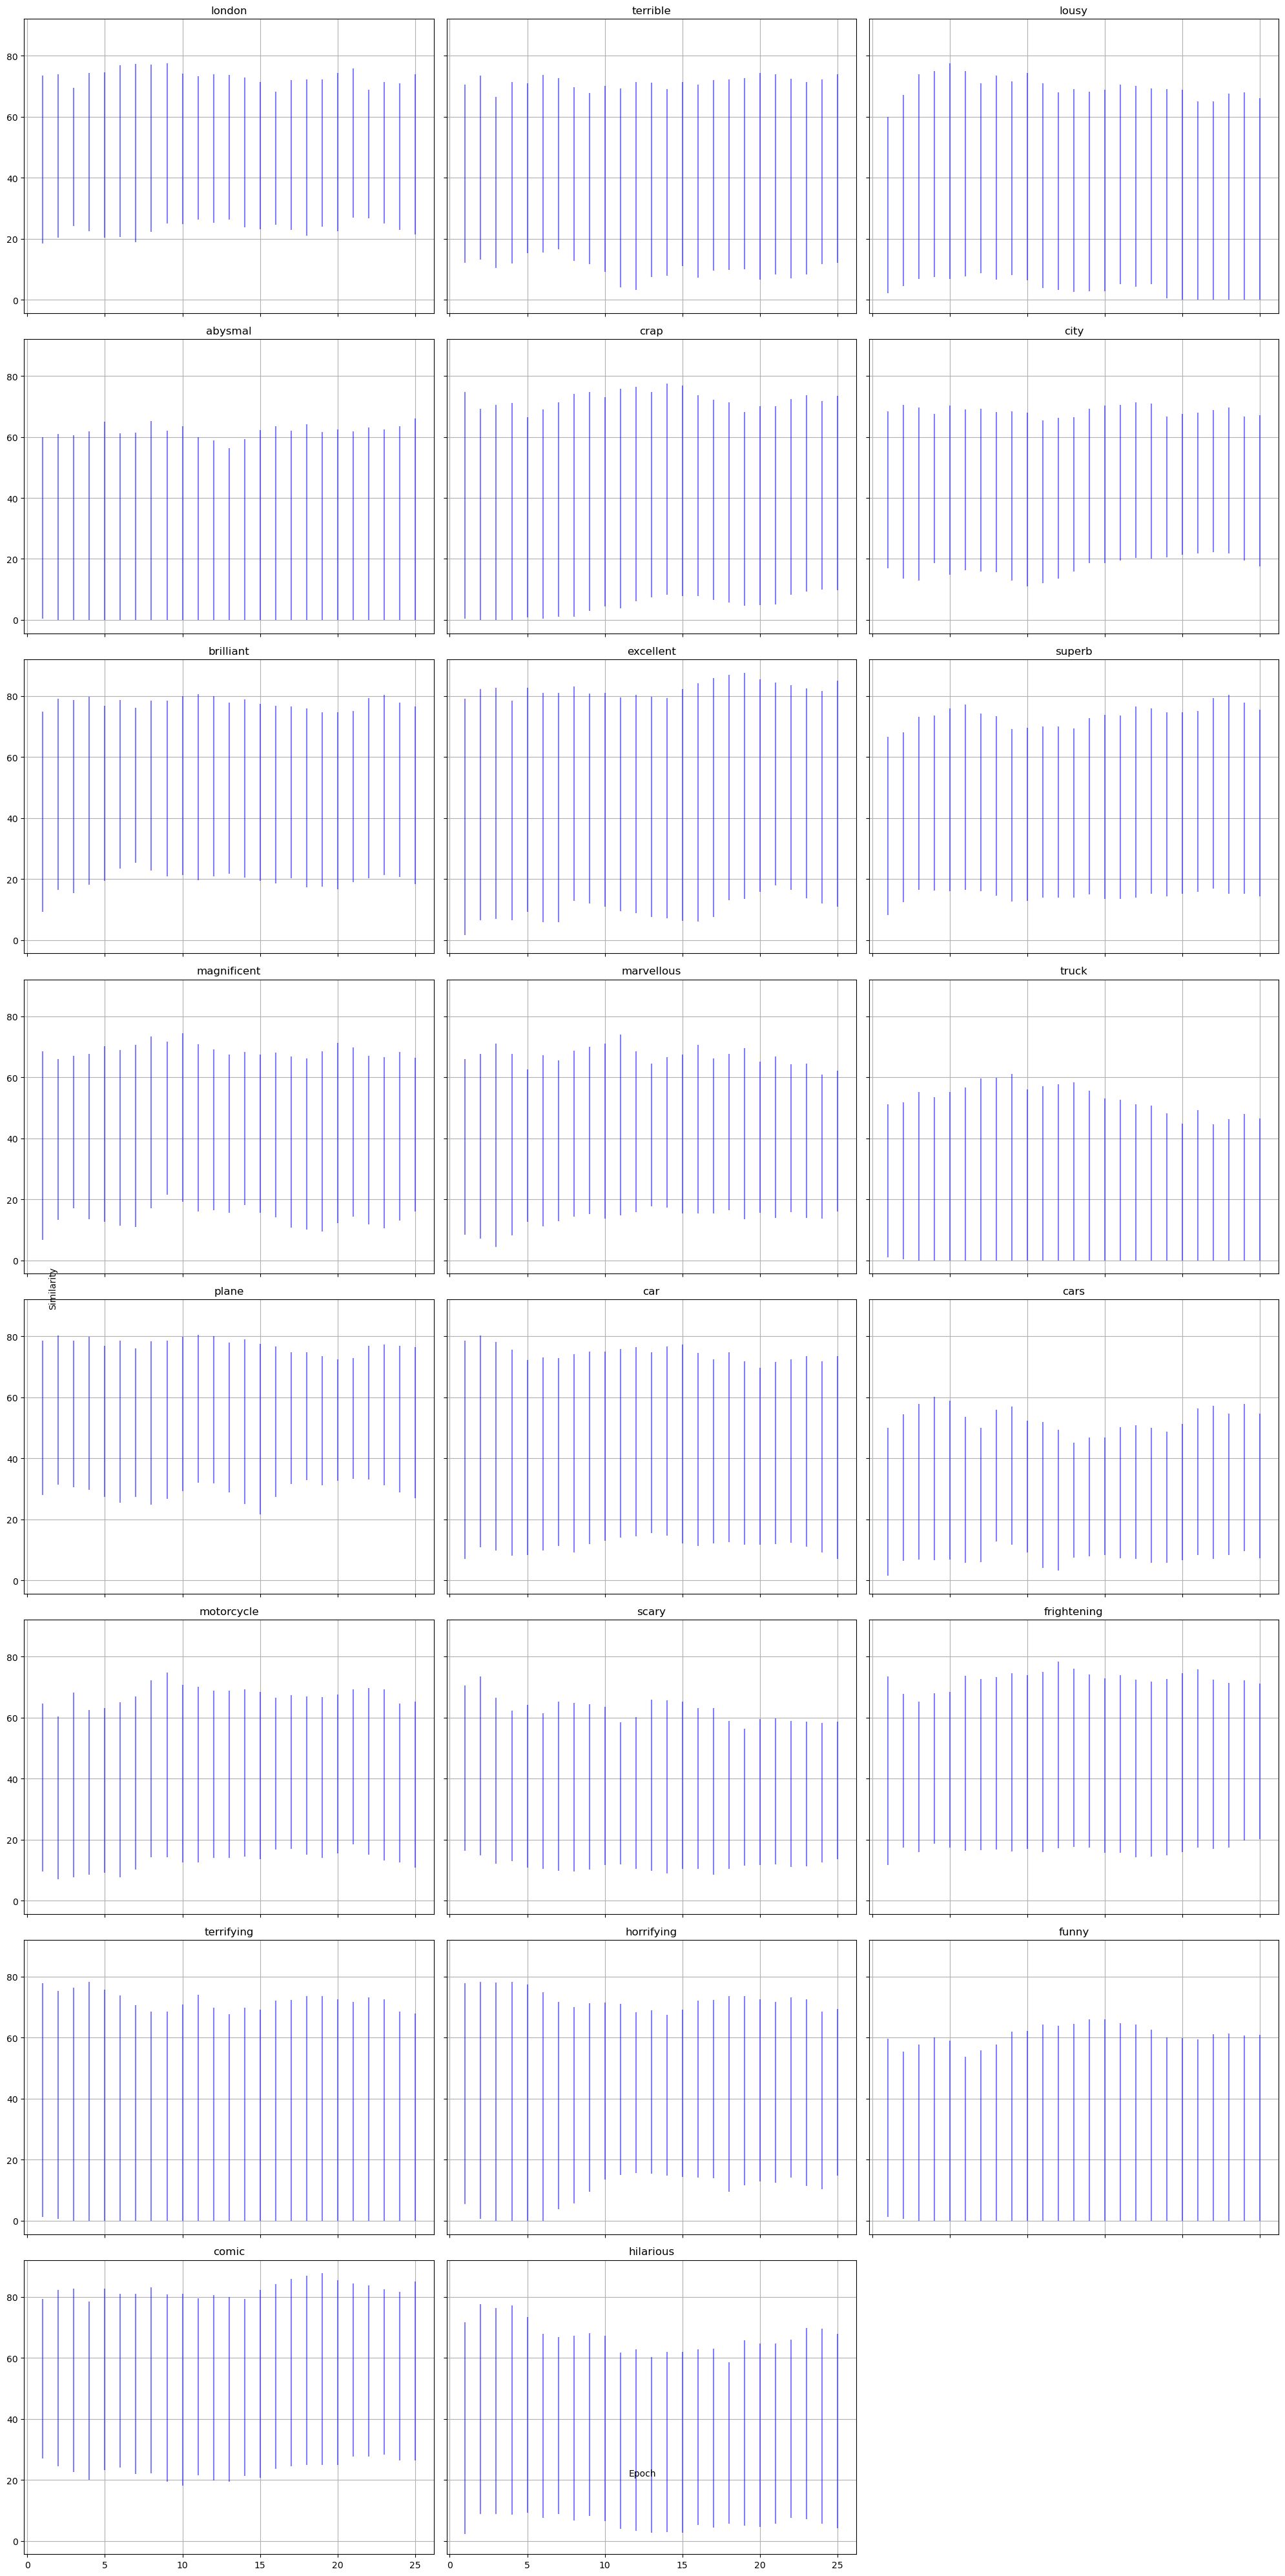

In [33]:
target_words_fluctuations = []
target_word_indices = [target_words.index(word) for word in target_words]
fluctuations_int = np.array(fluctuations.copy())
for target_word_index in target_word_indices:
    target_words_fluctuations.append([[float(item[1]), float(item[2])] for item in fluctuations_int[:, target_word_index]])


num_rows = int(np.ceil(len(target_words) / 3))  # Number of rows in the grid (assumes 3 columns)
fig, axes = plt.subplots(num_rows, 3, figsize=(20, 40), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat):
    if i < len(target_words_fluctuations):
        target_word_fluctuations = target_words_fluctuations[i]
        for epoch, similarity in enumerate(target_word_fluctuations):
            ax.vlines(epoch+1, similarity[0], similarity[1], color='blue', alpha=0.5)  # Set alpha to add transparency to lines

        ax.set_title(target_words[i])
        ax.grid(True)

fig.delaxes(axes[-1, -1])  # Remove any unnecessary subplot

fig.text(0.5, 0.04, 'Epoch', ha='center')  # Common x-axis label
fig.text(0.04, 0.5, 'Similarity', va='center', rotation='vertical')  # Common y-axis label
plt.tight_layout()  # Adjust spacing between subplots
result_image_name = f"fluctuations_{test_id}.png"
result_image_path = os.path.join(test_dir, result_image_name)
plt.savefig(result_image_path, dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Create a new folder for this run of the script
if not os.path.exists('color_plots'):
    os.makedirs('color_plots')
plot_filename = f'color_plots/plot_{clauses}.png'

# Create a new 3D array with the same shape as list_of_words, with dtype=np.uint8
color_array = np.zeros((len(list_of_words), len(list_of_words[0]), 3), dtype=np.uint8)

# Loop through each element in the array and replace the word with its corresponding color
for i in range(len(list_of_words)):
    for j in range(len(list_of_words[i])):
        word = list_of_words[i][j]
        # Replace the word with its corresponding color
        color = color_dict[word]
        r, g, b = mcolors.hex2color(color)
        color_array[i][j] = np.array([r*255, g*255, b*255], dtype=np.uint8)

    # Add the row number in front of each row
    plt.text(-0.5, i, f'{target_words_with_min_max[i]}', ha='right', va='center')

# Create a plot of the color array
plt.imshow(color_array)
plt.axis('off')

# Add legends for each word color
legend_handles = []
legend_labels = []
for word, color in color_dict.items():
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=word, markerfacecolor=color, markersize=10))
    legend_labels.append(word)

plt.legend(handles=legend_handles, labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

# Save the plot as a PNG file
plt.savefig('color_plots/color_plot.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import logging

# Set the log level to suppress debug messages from matplotlib.font_manager
logging.getLogger("matplotlib.font_manager").setLevel(logging.INFO)

# Increase the number of samples in the dataset or decrease the perplexity
n_samples = similarity.shape[0]
perplexity = min(30, n_samples - 1)  # You can adjust the perplexity as needed

# Perform t-SNE with adjusted perplexity
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
embeddings = tsne.fit_transform(similarity)

# Plot the results
plt.figure(figsize=(8, 8))
for i, word in enumerate(target_words):
    plt.scatter(embeddings[i, 0], embeddings[i, 1])
    plt.text(embeddings[i, 0], embeddings[i, 1], word)

plt.title('t-SNE Visualization of Cosine Similarities')
plt.show()